In [1]:
from preprocessing.text_preprocessing import load_tokenizer
from preprocessing.image_preprocessing import get_train_transform
from dataset.medical_caption_dataset import MedicalCaptionDataset, create_dataloader

In [ ]:
from models.custom_mamba_decoder import MambaDecoder

In [ ]:

# Load tokenizer
tokenizer = load_tokenizer('data/vocab.json')
print(f"✓ Loaded tokenizer (vocab size: {len(tokenizer)})")

# Create image transform
image_transform = get_train_transform(image_size=224, augment=False)
print(f"✓ Created image transform")

✓ Loaded tokenizer (vocab size: 625)
✓ Created image transform
✓ Created DataLoader with 580 batches
✓ Created DataLoader with 125 batches

Testing batch loading...
  Batch image shape: torch.Size([4, 3, 224, 224])
  Batch caption_ids shape: torch.Size([4, 100])
  Batch caption lengths: tensor([41, 59, 16, 29])

✓ Dataset and DataLoader working correctly!


In [4]:
model = MambaDecoder(
    vocab_path='data/vocab.json'
)

Some weights of BlipVisionModel were not initialized from the model checkpoint at Salesforce/blip-image-captioning-base and are newly initialized: ['embeddings.class_embedding', 'embeddings.patch_embedding.bias', 'embeddings.patch_embedding.weight', 'embeddings.position_embedding', 'encoder.layers.0.layer_norm1.bias', 'encoder.layers.0.layer_norm1.weight', 'encoder.layers.0.layer_norm2.bias', 'encoder.layers.0.layer_norm2.weight', 'encoder.layers.0.mlp.fc1.bias', 'encoder.layers.0.mlp.fc1.weight', 'encoder.layers.0.mlp.fc2.bias', 'encoder.layers.0.mlp.fc2.weight', 'encoder.layers.0.self_attn.projection.bias', 'encoder.layers.0.self_attn.projection.weight', 'encoder.layers.0.self_attn.qkv.bias', 'encoder.layers.0.self_attn.qkv.weight', 'encoder.layers.1.layer_norm1.bias', 'encoder.layers.1.layer_norm1.weight', 'encoder.layers.1.layer_norm2.bias', 'encoder.layers.1.layer_norm2.weight', 'encoder.layers.1.mlp.fc1.bias', 'encoder.layers.1.mlp.fc1.weight', 'encoder.layers.1.mlp.fc2.bias', 'e

In [5]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import os
from pathlib import Path

# Training configuration
BATCH_SIZE = 8
NUM_EPOCHS = 3
LEARNING_RATE = 1e-4
WARMUP_EPOCHS = 1
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_DIR = Path('checkpoints/mamba_decoder')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

Device: cuda
Batch size: 8
Number of epochs: 3
Learning rate: 0.0001


In [6]:
# Create dataloaders with updated batch size
train_dataloader = create_dataloader(
    data_csv='data/train_data.csv',
    image_dir='data/images/images_normalized',
    tokenizer=tokenizer,
    image_transform=image_transform,
    batch_size=BATCH_SIZE,
    max_caption_length=100,
    shuffle=True,
    num_workers=2
)

val_dataloader = create_dataloader(
    data_csv='data/val_data.csv',
    image_dir='data/images/images_normalized',
    tokenizer=tokenizer,
    image_transform=image_transform,
    batch_size=BATCH_SIZE,
    max_caption_length=100,
    shuffle=False,
    num_workers=2
)

print(f"Train batches: {len(train_dataloader)}")
print(f"Val batches: {len(val_dataloader)}")

Train batches: 290
Val batches: 63


In [7]:
# Move model to device
model = model.to(DEVICE)

# Setup optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"✓ Model moved to {DEVICE}")
print(f"✓ Optimizer: AdamW with lr={LEARNING_RATE}")
print(f"✓ Scheduler: CosineAnnealingLR")

✓ Model moved to cuda
✓ Optimizer: AdamW with lr=0.0001
✓ Scheduler: CosineAnnealingLR


In [8]:
def train_epoch(model, dataloader, optimizer, device, epoch):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Training")
    
    for batch_idx, batch in enumerate(progress_bar):
        # Move batch to device
        pixel_values = batch['image'].to(device)
        caption_ids = batch['caption_ids'].to(device)
        
        # Forward pass
        # Use caption_ids as both input and labels
        # The model will shift them internally for language modeling
        labels = caption_ids.clone()
        labels[labels == tokenizer.pad_token] = -100
        outputs = model(
            pixel_values=pixel_values,
            input_ids=caption_ids,
            labels=labels
        )
        
        loss = outputs['loss']
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Update metrics
        total_loss += loss.item()
        avg_loss = total_loss / (batch_idx + 1)
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{avg_loss:.4f}'
        })
    
    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, device, epoch):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Validation")
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(progress_bar):
            # Move batch to device
            pixel_values = batch['image'].to(device)
            caption_ids = batch['caption_ids'].to(device)
            labels = caption_ids.clone()
            labels[labels == tokenizer.pad_token] = -100
            # Forward pass
            outputs = model(
                pixel_values=pixel_values,
                input_ids=caption_ids,
                labels=labels
            )
            
            loss = outputs['loss']
            total_loss += loss.item()
            avg_loss = total_loss / (batch_idx + 1)
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{avg_loss:.4f}'
            })
    
    return total_loss / len(dataloader)


print("✓ Training functions defined")

✓ Training functions defined


In [9]:
# Training loop
best_val_loss = float('inf')
train_losses = []
val_losses = []

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*60}")
    
    # Train
    train_loss = train_epoch(model, train_dataloader, optimizer, DEVICE, epoch)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate_epoch(model, val_dataloader, DEVICE, epoch)
    val_losses.append(val_loss)
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  LR:         {current_lr:.6f}")
    
    # Save checkpoint if best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint_path = CHECKPOINT_DIR / 'best_model.pt'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
        }, checkpoint_path)
        print(f"  ✓ Saved best model (val_loss: {val_loss:.4f})")
    
    # Save latest checkpoint
    checkpoint_path = CHECKPOINT_DIR / 'latest_model.pt'
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'best_val_loss': best_val_loss,
    }, checkpoint_path)

print(f"\n{'='*60}")
print("Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Checkpoints saved to: {CHECKPOINT_DIR}")

Starting training...


Epoch 1/3


Epoch 1 - Validation: 100%|██████████| 63/63 [00:13<00:00,  4.72it/s, loss=0.3140, avg_loss=0.7451]



Epoch 1 Summary:
  Train Loss: 0.9928
  Val Loss:   0.7451
  LR:         0.000075
  ✓ Saved best model (val_loss: 0.7451)

Epoch 2/3


Epoch 2 - Validation: 100%|██████████| 63/63 [00:13<00:00,  4.82it/s, loss=0.2755, avg_loss=0.6833]



Epoch 2 Summary:
  Train Loss: 0.5800
  Val Loss:   0.6833
  LR:         0.000025
  ✓ Saved best model (val_loss: 0.6833)

Epoch 3/3


Epoch 3 - Validation: 100%|██████████| 63/63 [00:13<00:00,  4.69it/s, loss=0.2799, avg_loss=0.6820]



Epoch 3 Summary:
  Train Loss: 0.4182
  Val Loss:   0.6820
  LR:         0.000000
  ✓ Saved best model (val_loss: 0.6820)

Training completed!
Best validation loss: 0.6820
Checkpoints saved to: checkpoints/mamba_decoder


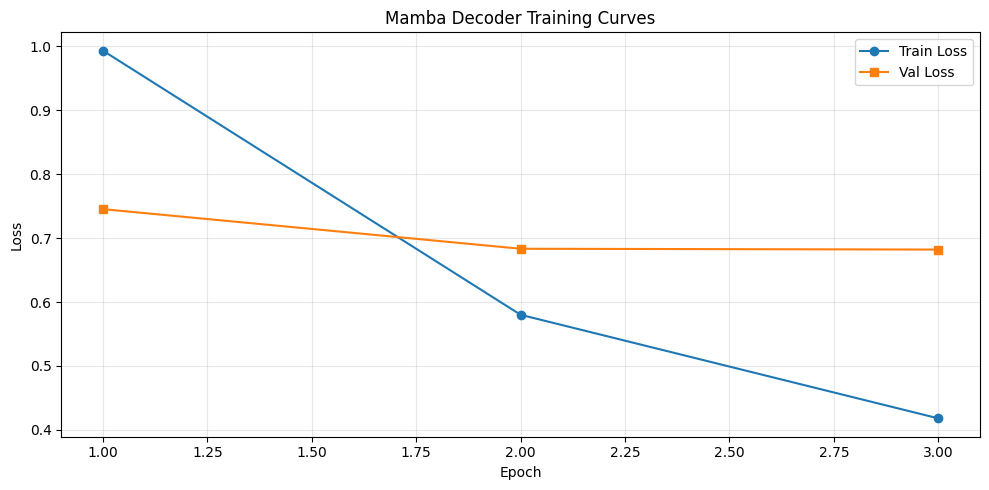

✓ Training curves saved to checkpoints/mamba_decoder/training_curves.png


In [10]:
# Plot training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Mamba Decoder Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'training_curves.png', dpi=150)
plt.show()

print(f"✓ Training curves saved to {CHECKPOINT_DIR / 'training_curves.png'}")

In [12]:
# Test generation on a few examples
test_dataloader = create_dataloader(
    data_csv='data/test_data.csv',
    image_dir='data/images/images_normalized',
    tokenizer=tokenizer,
    image_transform=image_transform,
    batch_size=BATCH_SIZE,
    max_caption_length=100,
    shuffle=False,
    num_workers=2
)

In [13]:
# Generate captions for all test data
print("Generating captions for test dataset...")
print(f"Test batches: {len(test_dataloader)}\n")

model.eval()
all_generated_captions = []
all_ground_truth_captions = []
all_image_ids = []

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_dataloader, desc="Generating captions")):
        # Move batch to device
        pixel_values = batch['image'].to(DEVICE)
        caption_ids = batch['caption_ids']
        
        # Generate captions
        generated_ids = model.generate(
            pixel_values=pixel_values,
            max_new_tokens=50,
            temperature=0.8,
            top_k=50,
            top_p=0.9
        )
        
        # Decode captions for each sample in the batch
        for i in range(generated_ids.shape[0]):
            # Decode generated caption
            gen_caption = model.decode_ids(generated_ids[i])
            all_generated_captions.append(gen_caption)
            
            # Decode ground truth caption
            gt_caption = model.decode_ids(caption_ids[i])
            all_ground_truth_captions.append(gt_caption)

print(f"\n✓ Generated {len(all_generated_captions)} captions")
print(f"✓ Total samples: {len(all_ground_truth_captions)}")

# Display first 5 examples
print("\nFirst 5 Examples:")
print("="*80)
for i in range(min(5, len(all_generated_captions))):
    print(f"\nSample {i+1}:")
    print(f"  Ground Truth: {all_ground_truth_captions[i]}")
    print(f"  Generated:    {all_generated_captions[i]}")
    print("-"*80)

Generating captions for test dataset...
Test batches: 62



Generating captions: 100%|██████████| 62/62 [00:14<00:00,  4.27it/s]


✓ Generated 491 captions
✓ Total samples: 491

First 5 Examples:

Sample 1:
  Ground Truth: heart size within normal limits , stable mediastinal and hilar contours . mild hyperinflation appears similar to prior . no focal alveolar consolidation , no definite pleural effusion seen . scattered chronic appearing irregular interstitial markings , no typical findings of pulmonary edema .
  Generated:    the heart is normal in size . the mediastinum is unremarkable . the lungs are clear .
--------------------------------------------------------------------------------

Sample 2:
  Ground Truth: no focal areas of consolidation . no suspicious pulmonary opacities . heart size within normal limits . no pleural effusions . no evidence of pneumothorax . osseous structures intact .
  Generated:    the heart size is upper limits of normal . the pulmonary xxxx and mediastinum are within normal limits . there is no pleural effusion or pneumothorax . there is no focal air space opacity to suggest a p

In [24]:
import pandas as pd
from lora.components.metrics import calculate_bleu, calculate_meteor, calculate_cider, calculate_radgraph_f1

In [17]:
df_test = pd.read_csv('data/test_data.csv')

In [18]:
df_test['generated_captions'] = all_generated_captions

In [20]:
df_test['generated_captions'].iloc[-5]

'the heart is normal in size . the mediastinum is unremarkable . the lungs are clear .'

In [21]:
df_test['findings'].iloc[-5]

'Heart size and mediastinal contour are normal. Pulmonary vascularity is normal. Lungs are clear. No pleural effusions or pneumothoraces.'

In [22]:
predictions = df_test['generated_captions'].values

In [27]:
df_test['generated_captions'].value_counts()

generated_captions
the heart is normal in size . the mediastinum is unremarkable . the lungs are clear .                                                                                                                                                                                  86
the heart is normal in size and contour . there is no mediastinal widening . the lungs are clear bilaterally . no large pleural effusion or pneumothorax . the xxxx are intact .                                                                                       27
the heart size and pulmonary vascularity appear within normal limits . the lungs are free of focal airspace disease . no pleural effusion or pneumothorax is seen .                                                                                                    23
the cardiomediastinal silhouette is normal in size and contour . no focal consolidation , pneumothorax or large pleural effusion . normal xxxx .                                       

In [23]:
references = df_test['findings'].values

In [25]:
bleu_score = calculate_bleu(generated_captions=predictions, ground_truth_captions=references)
cider_score = calculate_cider(generated_captions=predictions, ground_truth_captions=references)
meteor_score = calculate_meteor(generated_captions=predictions, ground_truth_captions=references)
radgraph_f1_score = calculate_radgraph_f1(generated_captions=predictions, ground_truth_captions=references)

[nltk_data] Downloading package wordnet to /home/user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/user/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Using device: cuda:0
model_type not provided, defaulting to radgraph-xl


In [26]:
print(bleu_score)
print(cider_score)
print(meteor_score)
print(radgraph_f1_score)

0.060247038144514625
0.05911489899362971
0.29234517742770033
0.27100575367038493
